<a href="https://colab.research.google.com/github/marsanla/C4L/blob/main/SOL_C4L_3_Funciones%2C_manejo_de_archivos%2C_bibliotecas_utiles_y_manejo_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Soluciones — Módulo 3: Funciones, archivos, librerías y datos

> Soluciones comentadas paso a paso. Todas las soluciones usan **funciones** y aplican las buenas prácticas vistas (`with open`, `try/except`, validación, docstrings).


## 3.1 Soluciones — funciones


### Ejercicio 1 — calcular_total


In [27]:
def calcular_total(lista):
    """Devuelve la suma de los elementos de la lista."""
    return sum(lista)


# Pruebas
pagos_legales_1 = [100, 200, 300]
pagos_legales_2 = [400, 500, 600]
print("Total de pagos 1:", calcular_total(pagos_legales_1))   # 600
print("Total de pagos 2:", calcular_total(pagos_legales_2))   # 1500

# Explicación:
# - sum() es una función integrada que suma cualquier iterable de números.
# - Encapsularla en `calcular_total` da nombre semántico al concepto.


Total de pagos 1: 600
Total de pagos 2: 1500


### Ejercicio 2 — crear_informe


In [28]:
def crear_informe(nombre, facturas, pagado):
    total = sum(facturas)
    estado = "PAGADO" if pagado else "PENDIENTE DE PAGO"
    informe = f"Cliente {nombre} — Total: {total}€ — {estado}"
    print(informe)
    return informe


reporte = crear_informe("Juan Pérez", [150, 450, 200], False)

# Explicación:
# - Usamos un f-string + expresión condicional inline para el estado.
# - La función AMBAS imprime y devuelve el informe (útil si luego queremos
#   guardarlo en un archivo, por ejemplo).


Cliente Juan Pérez — Total: 800€ — PENDIENTE DE PAGO


### Ejercicio 3 — validar_caso


In [29]:
def validar_caso(numero, abierto):
    return numero > 0 and abierto


print("Caso 500 (abierto):", validar_caso(500,  True))   # True
print("Caso -10 (abierto):", validar_caso(-10,  True))   # False
print("Caso 50 (cerrado):",  validar_caso( 50, False))   # False

# Explicación:
# - `numero > 0 and abierto` ya devuelve un booleano directamente.
# - No hace falta `if ... return True else return False`.


Caso 500 (abierto): True
Caso -10 (abierto): False
Caso 50 (cerrado): False


### Ejercicio 4 — asignar_abogado


In [30]:
def asignar_abogado(tipo_caso, urgencia):
    abogados = {
        "civil": "Carmen Ruiz",
        "penal": "Juan Soto",
    }
    nombre = abogados.get(tipo_caso.lower(), "Asignación pendiente")
    if urgencia.lower() == "alta":
        nombre += " [URGENTE]"
    return nombre


print(asignar_abogado("civil",   "alta"))   # Carmen Ruiz [URGENTE]
print(asignar_abogado("penal",   "baja"))   # Juan Soto
print(asignar_abogado("laboral", "alta"))   # Asignación pendiente [URGENTE]

# Explicación:
# - Diccionario tipo_caso -> abogado, con .get() para tener un valor por defecto.
# - Comparamos en minúsculas para tolerar variaciones.


Carmen Ruiz [URGENTE]
Juan Soto
Asignación pendiente [URGENTE]


### Ejercicio 5 — dividir con manejo de excepciones


In [31]:
def dividir(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        print("ERROR: división entre cero. Devuelvo None.")
        return None


print("10 / 2 =", dividir(10, 2))    # 5.0
print("10 / 0 =", dividir(10, 0))    # None (con aviso)

# Explicación:
# - try/except captura la excepción para que el programa NO se rompa.
# - ZeroDivisionError es el tipo concreto que lanza Python al dividir entre 0.
# - Capturamos solo lo que esperamos (no usar `except:` a secas).


10 / 2 = 5.0
ERROR: división entre cero. Devuelvo None.
10 / 0 = None


### Ejercicio 6 — Tests para dividir


In [32]:
# Pruebas unitarias
assert dividir(10, 2) == 5.0
assert dividir(0, 5) == 0.0
assert dividir(10, 0) is None
assert dividir(-10, 2) == -5.0

print("Todos los tests pasaron correctamente.")

# Explicación:
# - assert lanza AssertionError si la expresión es falsa.
# - Es la forma más rápida de verificar que una función se comporta
#   como esperamos.


ERROR: división entre cero. Devuelvo None.
Todos los tests pasaron correctamente.


## 3.2 Soluciones — manejo de archivos


### Ejercicio 7 — Escribir CSV


In [33]:
import csv

def escribir_csv(datos, nombre_archivo):
    """Escribe una lista de diccionarios en un archivo CSV."""
    if not datos:
        print("La lista está vacía, no hay nada que escribir.")
        return

    nombres_columnas = datos[0].keys()       # tomamos las claves del primer dict como cabecera

    with open(nombre_archivo, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=nombres_columnas)
        writer.writeheader()
        writer.writerows(datos)
    print(f"Archivo '{nombre_archivo}' creado con {len(datos)} registros.")


datos_casos = [
    {"nombre": "Caso 1", "fecha": "2021-01-01", "resultado": "Ganado"},
    {"nombre": "Caso 2", "fecha": "2021-02-01", "resultado": "Perdido"}
]
escribir_csv(datos_casos, "casos.csv")

# Explicación:
# - csv.DictWriter es más cómodo que csv.writer cuando tenemos diccionarios.
# - newline="" evita líneas vacías extra en Windows.
# - encoding="utf-8" para que las tildes se guarden bien.


Archivo 'casos.csv' creado con 2 registros.


### Ejercicio 8 — Leer archivo de texto


In [34]:
def leer_archivo_texto(nombre_archivo):
    try:
        with open(nombre_archivo, "r", encoding="utf-8") as f:
            for linea in f:
                print(linea.strip())     # .strip() quita el salto de línea final
    except FileNotFoundError:
        print(f"ERROR: el archivo '{nombre_archivo}' no existe.")


leer_archivo_texto("casos.csv")

# Explicación:
# - `for linea in f:` recorre el archivo línea a línea (eficiente con archivos grandes).
# - try/except evita que el programa se rompa si falta el archivo.


nombre,fecha,resultado
Caso 1,2021-01-01,Ganado
Caso 2,2021-02-01,Perdido


### Ejercicio 9 — CSV a JSON


In [35]:
import csv
import json

def csv_a_json(nombre_archivo_csv, nombre_archivo_json):
    """Convierte un CSV en JSON."""
    # 1) Leer el CSV como lista de diccionarios
    with open(nombre_archivo_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        datos = list(reader)            # convertimos el iterador en lista

    # 2) Escribir el JSON
    with open(nombre_archivo_json, "w", encoding="utf-8") as f:
        json.dump(datos, f, ensure_ascii=False, indent=2)

    print(f"Convertidos {len(datos)} registros a {nombre_archivo_json}")


csv_a_json("casos.csv", "casos.json")

# Explicación:
# - csv.DictReader convierte cada fila en un diccionario automáticamente.
# - json.dump con indent=2 produce un JSON legible.
# - ensure_ascii=False permite tildes y eñes legibles.


Convertidos 2 registros a casos.json


### Ejercicio 10 — Leer JSON


In [36]:
import json

def leer_json(nombre_archivo):
    with open(nombre_archivo, "r", encoding="utf-8") as f:
        datos = json.load(f)

    for caso in datos:
        nombre = caso.get("nombre", "?")
        resultado = caso.get("resultado", "?")
        print(f"{nombre} — {resultado}")


leer_json("casos.json")

# Explicación:
# - json.load() lee y devuelve la estructura Python (dict o list).
# - .get(clave, valor_por_defecto) evita errores si una clave falta.


Caso 1 — Ganado
Caso 2 — Perdido


## 3.3 Soluciones — librerías útiles


### Setup — generar el CSV de partida


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datos = {
    "CasoID":       [1, 2, 3, 4, 5],
    "TipoCaso":     ["Civil", "Penal", "Civil", "Penal", "Civil"],
    "ValorDisputa": [50000, 200000, 75000, 50000, -120000],
    "Resuelto":     [False, True, False, True, False],
    "FechaCaso":    ["2022/01/12", "2023/11/09", "2022/02/1", "2024/01/12", "2020/11/12"]
}

df = pd.DataFrame(datos)
df.to_csv("datos_casos_legales.csv", index=False)
print(df)


   CasoID TipoCaso  ValorDisputa  Resuelto   FechaCaso
0       1    Civil         50000     False  2022/01/12
1       2    Penal        200000      True  2023/11/09
2       3    Civil         75000     False   2022/02/1
3       4    Penal         50000      True  2024/01/12
4       5    Civil       -120000     False  2020/11/12


### Ejercicio 11 — Filtrar casos por umbral


In [38]:
import pandas as pd

def analizar_datos_casos(archivo_csv, umbral_valor):
    """Filtra casos cuya cuantía supera el umbral y guarda el resultado."""
    df = pd.read_csv(archivo_csv)
    casos_grandes = df[df["ValorDisputa"] > umbral_valor]
    casos_grandes.to_csv("casos_filtrados.csv", index=False)
    return casos_grandes


casos = analizar_datos_casos("datos_casos_legales.csv", 100_000)
print(casos)

# Explicación:
# - df[condición] devuelve solo las filas que cumplen la condición.
# - df.to_csv(..., index=False) guarda sin la columna de índice.


   CasoID TipoCaso  ValorDisputa  Resuelto   FechaCaso
1       2    Penal        200000      True  2023/11/09


### Ejercicio 12 — Promedio con numpy


In [39]:
import numpy as np

def calcular_promedio_compensaciones(compensaciones):
    return np.mean(compensaciones)


print(calcular_promedio_compensaciones([20_000, 30_000, 25_000]))   # 25000.0

# Explicación:
# - np.mean() acepta listas, tuplas o arrays de numpy.
# - Devuelve un float.


25000.0


### Ejercicio 13 — Gráfico de barras


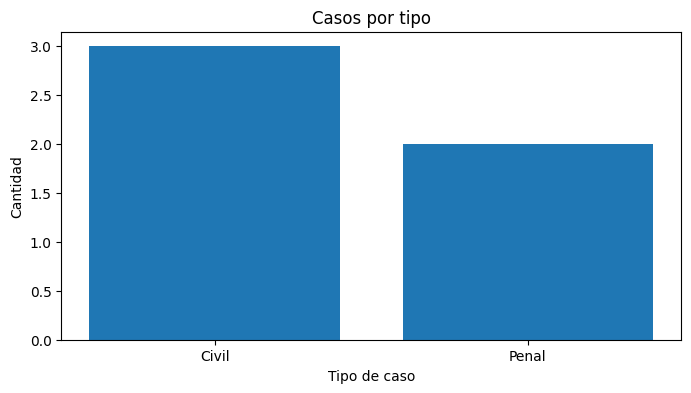

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

def grafico_barras_casos(tipos_casos):
    """Dibuja un gráfico de barras con la cantidad de casos por tipo."""
    conteo = tipos_casos.value_counts()

    plt.figure(figsize=(8, 4))
    plt.bar(conteo.index, conteo.values)
    plt.title("Casos por tipo")
    plt.xlabel("Tipo de caso")
    plt.ylabel("Cantidad")
    plt.show()


grafico_barras_casos(pd.Series(["Civil", "Penal", "Civil", "Civil", "Penal"]))

# Explicación:
# - .value_counts() devuelve una Series con las categorías y su frecuencia.
# - plt.bar(etiquetas, valores) dibuja el gráfico de barras.


### Ejercicio 14 — Casos por mes


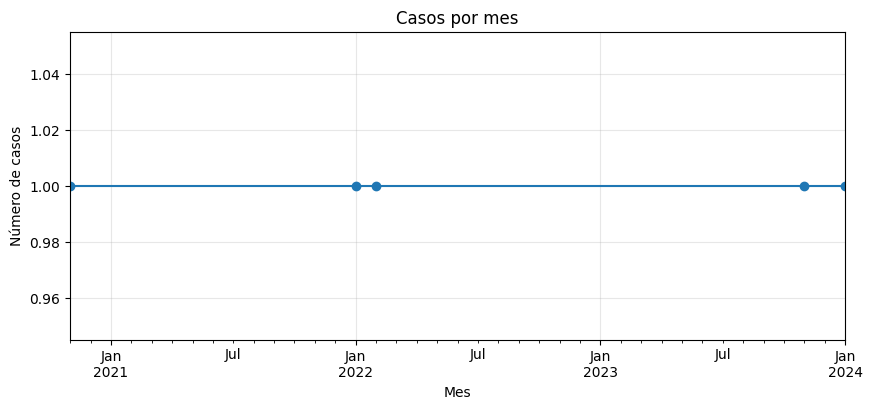

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

def visualizar_casos_por_mes(datos_csv):
    df = pd.read_csv(datos_csv)
    df["FechaCaso"] = pd.to_datetime(df["FechaCaso"], errors="coerce")

    # Eliminar fechas no válidas
    df = df.dropna(subset=["FechaCaso"])

    # Agrupar por mes
    por_mes = df.groupby(df["FechaCaso"].dt.to_period("M")).size()

    plt.figure(figsize=(10, 4))
    por_mes.plot(kind="line", marker="o")
    plt.title("Casos por mes")
    plt.xlabel("Mes")
    plt.ylabel("Número de casos")
    plt.grid(True, alpha=0.3)
    plt.show()


visualizar_casos_por_mes("datos_casos_legales.csv")

# Explicación:
# - errors="coerce" convierte las fechas no válidas en NaT (no rompe).
# - dropna() elimina las filas con NaT.
# - .dt.to_period("M") agrupa por mes-año.


## 3.4 Soluciones — manejo de datos


### Setup


In [42]:
datos = {
    "CasoID":       [1, 2, 3, 4, 5],
    "TipoCaso":     ["Civil", "Penal", "Civil", "Penal", "Civil"],
    "ValorDisputa": [50000, 200000, 75000, 50000, -120000],
    "Resuelto":     [False, True, False, None, False],
    "FechaCaso":    ["2022/01/12", None, None, None, None]
}

df = pd.DataFrame(datos)
df.to_csv("casos_legales.csv", index=False)


### Ejercicio 15 — Limpieza de datos


In [43]:
import pandas as pd

def limpiar_datos(nombre_archivo):
    """Carga el CSV y aplica las limpiezas habituales."""
    df = pd.read_csv(nombre_archivo)

    # 1) Convertir FechaCaso a datetime (las no válidas se convierten en NaT)
    df["FechaCaso"] = pd.to_datetime(df["FechaCaso"], errors="coerce")

    # 2) Descartar filas con valores negativos en ValorDisputa
    df = df[df["ValorDisputa"] >= 0]

    # 3) Rellenar Resuelto vacíos con False
    df["Resuelto"] = df["Resuelto"].fillna(False)

    return df


datos_limpio = limpiar_datos("casos_legales.csv")
print(datos_limpio)

# Explicación:
# - errors="coerce" no rompe con fechas mal formateadas (las marca NaT).
# - df[condición] filtra filas.
# - .fillna(valor) reemplaza valores ausentes.


   CasoID TipoCaso  ValorDisputa  Resuelto  FechaCaso
0       1    Civil         50000     False 2022-01-12
1       2    Penal        200000      True        NaT
2       3    Civil         75000     False        NaT
3       4    Penal         50000     False        NaT


/var/folders/b2/gmtcx7p173g1_nw7ppz4grbc0000gn/T/ipykernel_39031/4184280234.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Resuelto"] = df["Resuelto"].fillna(False)


### Ejercicio 16 — Organizar casos por tipo


In [44]:
def organizar_casos(datos, tipo=None):
    if tipo is not None:
        return [c for c in datos if c["TipoCaso"] == tipo]
    # Si no se pasa tipo, devolvemos un dict {tipo: [casos...]}
    agrupados = {}
    for caso in datos:
        agrupados.setdefault(caso["TipoCaso"], []).append(caso)
    return agrupados


datos_ejemplo = [
    {"CasoID": 1, "TipoCaso": "Civil", "Detalle": "Disputa contractual"},
    {"CasoID": 2, "TipoCaso": "Penal", "Detalle": "Fraude"},
    {"CasoID": 3, "TipoCaso": "Civil", "Detalle": "Reclamación cantidad"},
]

print("Solo Civil:", organizar_casos(datos_ejemplo, "Civil"))
print("Todos agrupados:", organizar_casos(datos_ejemplo))

# Explicación:
# - List comprehension `[c for c in datos if ...]` para filtrar.
# - setdefault(clave, valor) crea la entrada si no existe; útil para
#   agrupar elementos en listas dentro de un diccionario.


Solo Civil: [{'CasoID': 1, 'TipoCaso': 'Civil', 'Detalle': 'Disputa contractual'}, {'CasoID': 3, 'TipoCaso': 'Civil', 'Detalle': 'Reclamación cantidad'}]
Todos agrupados: {'Civil': [{'CasoID': 1, 'TipoCaso': 'Civil', 'Detalle': 'Disputa contractual'}, {'CasoID': 3, 'TipoCaso': 'Civil', 'Detalle': 'Reclamación cantidad'}], 'Penal': [{'CasoID': 2, 'TipoCaso': 'Penal', 'Detalle': 'Fraude'}]}


## 3.5 Solución del proyecto integrador — Sistema de gestión documental

Esta es la solución completa del proyecto. Cada función tiene **una responsabilidad** y se prueba por separado, siguiendo las buenas prácticas vistas.


### Preparación — descargar archivos de muestra


In [45]:
# ============================================================
# Generamos archivos de muestra LOCALMENTE — sin descargas externas.
#
# Antes el proyecto descargaba un .zip desde GitHub y lo descomprimía
# en /content/ (ruta de Google Colab). Eso no funciona si ejecutas
# este notebook en local. Aquí creamos los archivos de cero, lo que
# además te permite EXPERIMENTAR cambiando los datos.
# ============================================================
import pandas as pd
import json
import os
import random
from datetime import datetime, timedelta

random.seed(42)   # para que los datos generados sean siempre los mismos


def _generar_casos(num=20, semilla=0):
    """Crea una lista de diccionarios con casos legales simulados."""
    random.seed(semilla)
    tipos     = ["Civil", "Penal", "Comercial", "Familia", "Laboral"]
    abogados  = ["Juan Pérez", "Ana Gómez", "Carlos Ruiz"]
    casos = []
    for i in range(num):
        casos.append({
            "CasoID":       1000 + i,
            "TipoCaso":     random.choice(tipos),
            "Abogado":      random.choice(abogados),
            "ValorDisputa": random.randint(5_000, 250_000),
            "Resuelto":     random.choice([True, False]),
            "FechaCaso":    (datetime.now() - timedelta(days=random.randint(30, 700))).strftime("%Y-%m-%d"),
        })
    return casos


# Carpeta de trabajo (relativa al notebook)
DATA_DIR = "datos_proyecto"
os.makedirs(DATA_DIR, exist_ok=True)

# Generamos 2 CSVs y 2 JSONs como simularía un departamento real
casos_1 = _generar_casos(num=15, semilla=1)
casos_2 = _generar_casos(num=15, semilla=2)
casos_3 = _generar_casos(num=15, semilla=3)
casos_4 = _generar_casos(num=15, semilla=4)

pd.DataFrame(casos_1).to_csv(f"{DATA_DIR}/casos_legales_1.csv", index=False)
pd.DataFrame(casos_3).to_csv(f"{DATA_DIR}/casos_legales_2.csv", index=False)

with open(f"{DATA_DIR}/casos_legales_1.json", "w", encoding="utf-8") as f:
    json.dump(casos_2, f, ensure_ascii=False, indent=2)
with open(f"{DATA_DIR}/casos_legales_2.json", "w", encoding="utf-8") as f:
    json.dump(casos_4, f, ensure_ascii=False, indent=2)

print(f"Archivos generados en '{DATA_DIR}/':")
for f in sorted(os.listdir(DATA_DIR)):
    print(f"  - {f}")


Archivos generados en 'datos_proyecto/':
  - casos_legales_1.csv
  - casos_legales_1.json
  - casos_legales_2.csv
  - casos_legales_2.json


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os


### Función 1 — Cargar y unir datos


In [47]:
def cargar_datos(fuentes_datos):
    """Carga múltiples archivos CSV o JSON y los une en un solo DataFrame."""
    dfs = []
    for fuente in fuentes_datos:
        if fuente.endswith(".csv"):
            df = pd.read_csv(fuente)
        elif fuente.endswith(".json"):
            df = pd.read_json(fuente)
        else:
            print(f"AVISO: ignorado formato no soportado -> {fuente}")
            continue
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()    # devolvemos un DataFrame vacío si no hay nada
    return pd.concat(dfs, ignore_index=True)


# Explicación:
# - Iteramos por cada fuente y leemos según extensión.
# - pd.concat une la lista de DataFrames en uno solo.
# - ignore_index=True reinicia los índices.


### Función 2 — Análisis básico


In [48]:
def analizar_datos(datos):
    """Devuelve total de casos, valor medio en disputa y tasa de éxito."""
    total_casos = len(datos)
    promedio_disputa = datos["ValorDisputa"].mean() if total_casos else 0
    if total_casos:
        tasa_exito = (datos["Resuelto"].sum() / total_casos) * 100
    else:
        tasa_exito = 0
    return total_casos, promedio_disputa, tasa_exito


### Función 3 — Detectar casos urgentes


In [49]:
def procesar_datos(datos):
    """Devuelve los casos urgentes: ValorDisputa > 100.000 y Resuelto == False."""
    return datos[(datos["ValorDisputa"] > 100_000) & (~datos["Resuelto"].astype(bool))]

# Explicación:
# - En pandas, `&` es Y lógico para columnas booleanas (no usar `and`).
# - `~` es la negación.
# - Los paréntesis alrededor de cada condición son OBLIGATORIOS.


### Función 4 — Visualización


In [50]:
def visualizar_datos(datos):
    """Dibuja un gráfico de barras con la cantidad de casos por tipo."""
    conteo = datos["TipoCaso"].value_counts()

    plt.figure(figsize=(8, 4))
    plt.bar(conteo.index, conteo.values, color="steelblue")
    plt.title("Casos por tipo")
    plt.xlabel("Tipo")
    plt.ylabel("Número de casos")
    plt.show()


### Función 5 — Generar informe CSV


In [51]:
def generar_informe(datos, filename="informe_casos.csv"):
    total, promedio, tasa = analizar_datos(datos)
    urgentes = procesar_datos(datos)

    # Resumen como DataFrame
    resumen = pd.DataFrame({
        "Total casos":               [total],
        "Promedio valor en disputa": [promedio],
        "Tasa de éxito (%)":         [tasa],
        "Casos urgentes":            [len(urgentes)],
    })
    resumen.to_csv(filename, index=False)
    print(f"Informe CSV guardado en: {filename}")
    return resumen


### Función 6 — main (orquestador)


SISTEMA DE GESTIÓN DOCUMENTAL — RESUMEN

Cargados 60 registros.
  Total de casos: 60
  Promedio valor: 139,640.95€
  Tasa de éxito:  43.3%
  Casos urgentes: 25


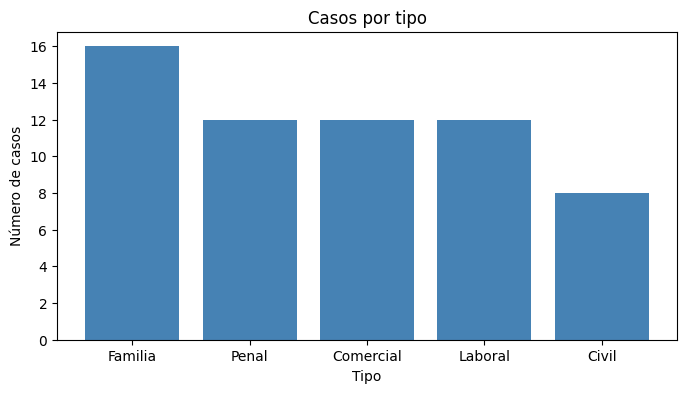

Informe CSV guardado en: informe_casos.csv


In [52]:
def main(archivos):
    """Pipeline completo del sistema de gestión."""
    print("=" * 60)
    print("SISTEMA DE GESTIÓN DOCUMENTAL — RESUMEN")
    print("=" * 60)

    # 1. Cargar
    datos = cargar_datos(archivos)
    print(f"\nCargados {len(datos)} registros.")

    # 2. Analizar
    total, promedio, tasa = analizar_datos(datos)
    print(f"  Total de casos: {total}")
    print(f"  Promedio valor: {promedio:,.2f}€")
    print(f"  Tasa de éxito:  {tasa:.1f}%")

    # 3. Procesar urgentes
    urgentes = procesar_datos(datos)
    print(f"  Casos urgentes: {len(urgentes)}")

    # 4. Visualizar
    visualizar_datos(datos)

    # 5. Generar informe
    generar_informe(datos)


# Lista de archivos a procesar (rutas RELATIVAS — funcionan en Colab y en local).
lista_archivos = [
    "datos_proyecto/casos_legales_1.csv",
    "datos_proyecto/casos_legales_1.json",
    "datos_proyecto/casos_legales_2.csv",
    "datos_proyecto/casos_legales_2.json",
]
main(lista_archivos)


## Cierra del módulo

Has aprendido las herramientas que distinguen a un script de juguete de uno **profesional**:

- **Funciones** con una sola responsabilidad y docstrings.
- **`with open`** y **`try/except`** para archivos seguros.
- **`pandas`**, **`numpy`** y **`matplotlib`** para manejo y visualización de datos.
- **Limpieza, agrupación y exportación** de datos reales.

> **Continuad con C4L_4** para una mini-introducción a IA y prompt engineering.
